# Baseline: PCA top-3 PC vs Dam GEGLU hyperplane regions\n
**목적:** GEGLU gate hyperplane 기반 region 분할의 baseline으로, PCA top-3 PC 부호로 동일한 8-way 분할을 수행하고 Dam(`04_DB_concept.ipynb`)과 비교한다


**선행:** `04_DB_concept.ipynb`에서 `inputs`, `images`, `region_id`(Dam)까지 실행하거나, 아래 load 셀에서 디스크 데이터 + `dam_region_id.npy` 로드.

In [12]:
import json
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

In [2]:
# 04_DB_concept.ipynb 와 동일 경로
CONCEPT = "dog"
TARGET_BLOCK = "up_blocks.1.attentions.1.transformer_blocks.0.ff.net.0"
K_select = 3
N_REGIONS = 2 ** K_select

SAVE_DIR = Path(f"/project/dam/data/{CONCEPT}")


def prompt_dir_name(prompt_idx: int, prompt: str) -> str:
    slug = prompt.lower().replace(" ", "_").replace("/", "_")[:40]
    return f"prompt_{prompt_idx:02d}_{slug}"

In [3]:
# --- Load inputs, images (04 cell 8–9) ---
with open(SAVE_DIR / "prompts.json", encoding="utf-8") as f:
    meta = json.load(f)
PROMPTS = meta["prompts"]
NUM_IMAGES_PER_PROMPT = meta["num_images_per_prompt"]

images, inputs_list = [], []
for p_idx, prompt in enumerate(PROMPTS):
    pdir = SAVE_DIR / prompt_dir_name(p_idx, prompt)
    n = NUM_IMAGES_PER_PROMPT
    images.extend([Image.open(pdir / "images" / f"{i:04d}.png") for i in range(n)])
    inputs_list.append(
        torch.load(pdir / TARGET_BLOCK.replace(".", "_") / "activations.pt")["inputs"].cpu()
    )

inputs = torch.cat(inputs_list, dim=0)  # (N, H*W, C)
N = inputs.shape[0]
print(f"inputs {tuple(inputs.shape)}, images {len(images)}")

inputs (100, 256, 1280), images 100


In [ ]:
# # --- Dam region_id (04 cell 19) ---
# dam_region_path = SAVE_DIR / "dam_region_id.npy"
# try:
#     region_id = np.asarray(region_id)  # 04 노트북에서 이미 계산된 경우
#     if not dam_region_path.exists():
#         np.save(dam_region_path, region_id)
#         print(f"saved Dam region_id → {dam_region_path}")
#     else:
#         print("using region_id from 04 (in memory)")
# except NameError:
#     if dam_region_path.exists():
#         region_id = np.load(dam_region_path)
#         print(f"loaded Dam region_id from {dam_region_path}")
#     else:
#         raise RuntimeError(
#             "Dam region_id 없음. 04_DB_concept.ipynb 셀 19 실행 후 다시 실행하거나,\n"
#             f"np.save(SAVE_DIR / 'dam_region_id.npy', region_id) 로 저장하세요."
#         )

# assert len(region_id) == N and region_id.min() >= 0 and region_id.max() < N_REGIONS
# print("Dam region distribution:", Counter(region_id))

RuntimeError: Dam region_id 없음. 04_DB_concept.ipynb 셀 19 실행 후 다시 실행하거나,
np.save(SAVE_DIR / 'dam_region_id.npy', region_id) 로 저장하세요.

In [7]:
region_id = np.array([2, 0, 7, 1, 0, 7, 3, 7, 7, 3, 5, 0, 1, 5, 0, 7, 7, 7, 0, 2, 7, 5,
       7, 7, 2, 0, 7, 0, 5, 7, 7, 3, 0, 6, 0, 7, 7, 5, 7, 7, 0, 7, 7, 7,
       0, 5, 7, 3, 7, 7, 7, 3, 5, 5, 5, 3, 7, 7, 2, 1, 1, 7, 0, 7, 6, 7,
       7, 0, 1, 3, 7, 1, 5, 0, 2, 2, 7, 7, 0, 3, 7, 2, 0, 0, 5, 0, 4, 5,
       0, 7, 7, 7, 5, 7, 3, 2, 7, 0, 2, 7])

In [5]:
# 1–3. PCA top-3 PC 부호 → region ID
image_repr = inputs.mean(dim=1).numpy()  # (N, C) token mean
pca = PCA(n_components=K_select)
pc_scores = pca.fit_transform(image_repr)  # (N, 3)

pc_signs = (pc_scores > 0).astype(int)
pca_region_id = pc_signs[:, 0] * 4 + pc_signs[:, 1] * 2 + pc_signs[:, 2]

print("PCA explained variance:", pca.explained_variance_ratio_)
print("PCA region distribution:", Counter(pca_region_id))

PCA explained variance: [0.31994423 0.08441579 0.07398668]
PCA region distribution: Counter({5: 15, 4: 14, 0: 14, 1: 14, 3: 12, 6: 12, 2: 11, 7: 8})


In [ ]:
def region_entropy(region_ids, n_regions=N_REGIONS):
    counts = np.bincount(region_ids, minlength=n_regions).astype(float)
    p = counts / counts.sum()
    p = p[p > 0]
    return -np.sum(p * np.log2(p))


dam_counts = np.array([Counter(region_id).get(r, 0) for r in range(N_REGIONS)])
pca_counts = np.array([Counter(pca_region_id).get(r, 0) for r in range(N_REGIONS)])
labels = [format(r, f"0{K_select}b") for r in range(N_REGIONS)]

ari = adjusted_rand_score(region_id, pca_region_id)
nmi = normalized_mutual_info_score(region_id, pca_region_id)
dam_H = region_entropy(region_id)
pca_H = region_entropy(pca_region_id)
more_imbalanced = "Dam" if dam_H < pca_H else "PCA" if pca_H < dam_H else "동일"

print(f"ARI = {ari:.4f}")
print(f"NMI = {nmi:.4f}")
print(f"Dam region entropy  = {dam_H:.4f} bits")
print(f"PCA region entropy  = {pca_H:.4f} bits")
print(f"더 imbalanced (lower H): {more_imbalanced}")

ARI = 0.1193
NMI = 0.3095
Dam region entropy  = 2.4240 bits
PCA region entropy  = 2.9778 bits
더 imbalanced (lower H): Dam


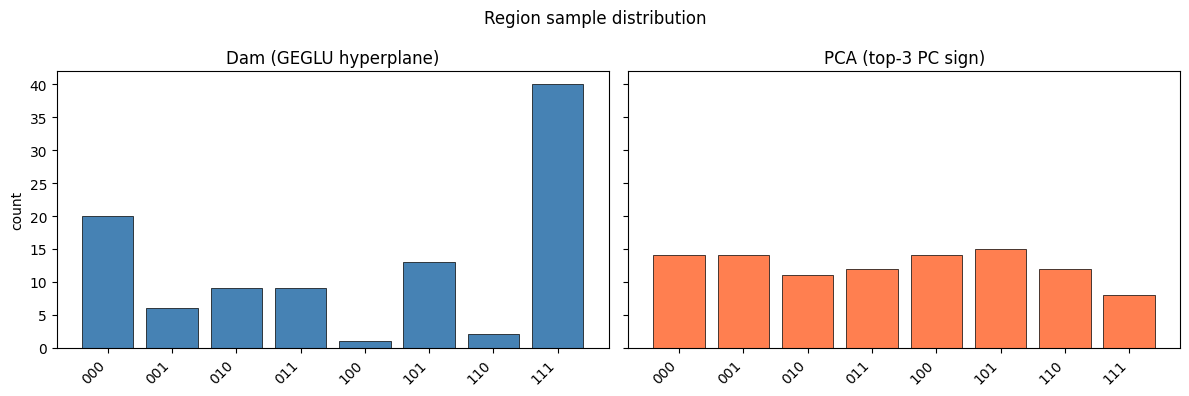

In [ ]:
# (a) Region별 sample 분포 — Dam vs PCA
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
x = np.arange(N_REGIONS)

axes[0].bar(x, dam_counts, color="steelblue", edgecolor="k", linewidth=0.5)
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=45, ha="right")
axes[0].set_title("Dam (GEGLU hyperplane)")
axes[0].set_ylabel("count")

axes[1].bar(x, pca_counts, color="coral", edgecolor="k", linewidth=0.5)
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=45, ha="right")
axes[1].set_title("PCA (top-3 PC sign)")

fig.suptitle("Region sample distribution", fontsize=12)
plt.tight_layout()
plt.show()

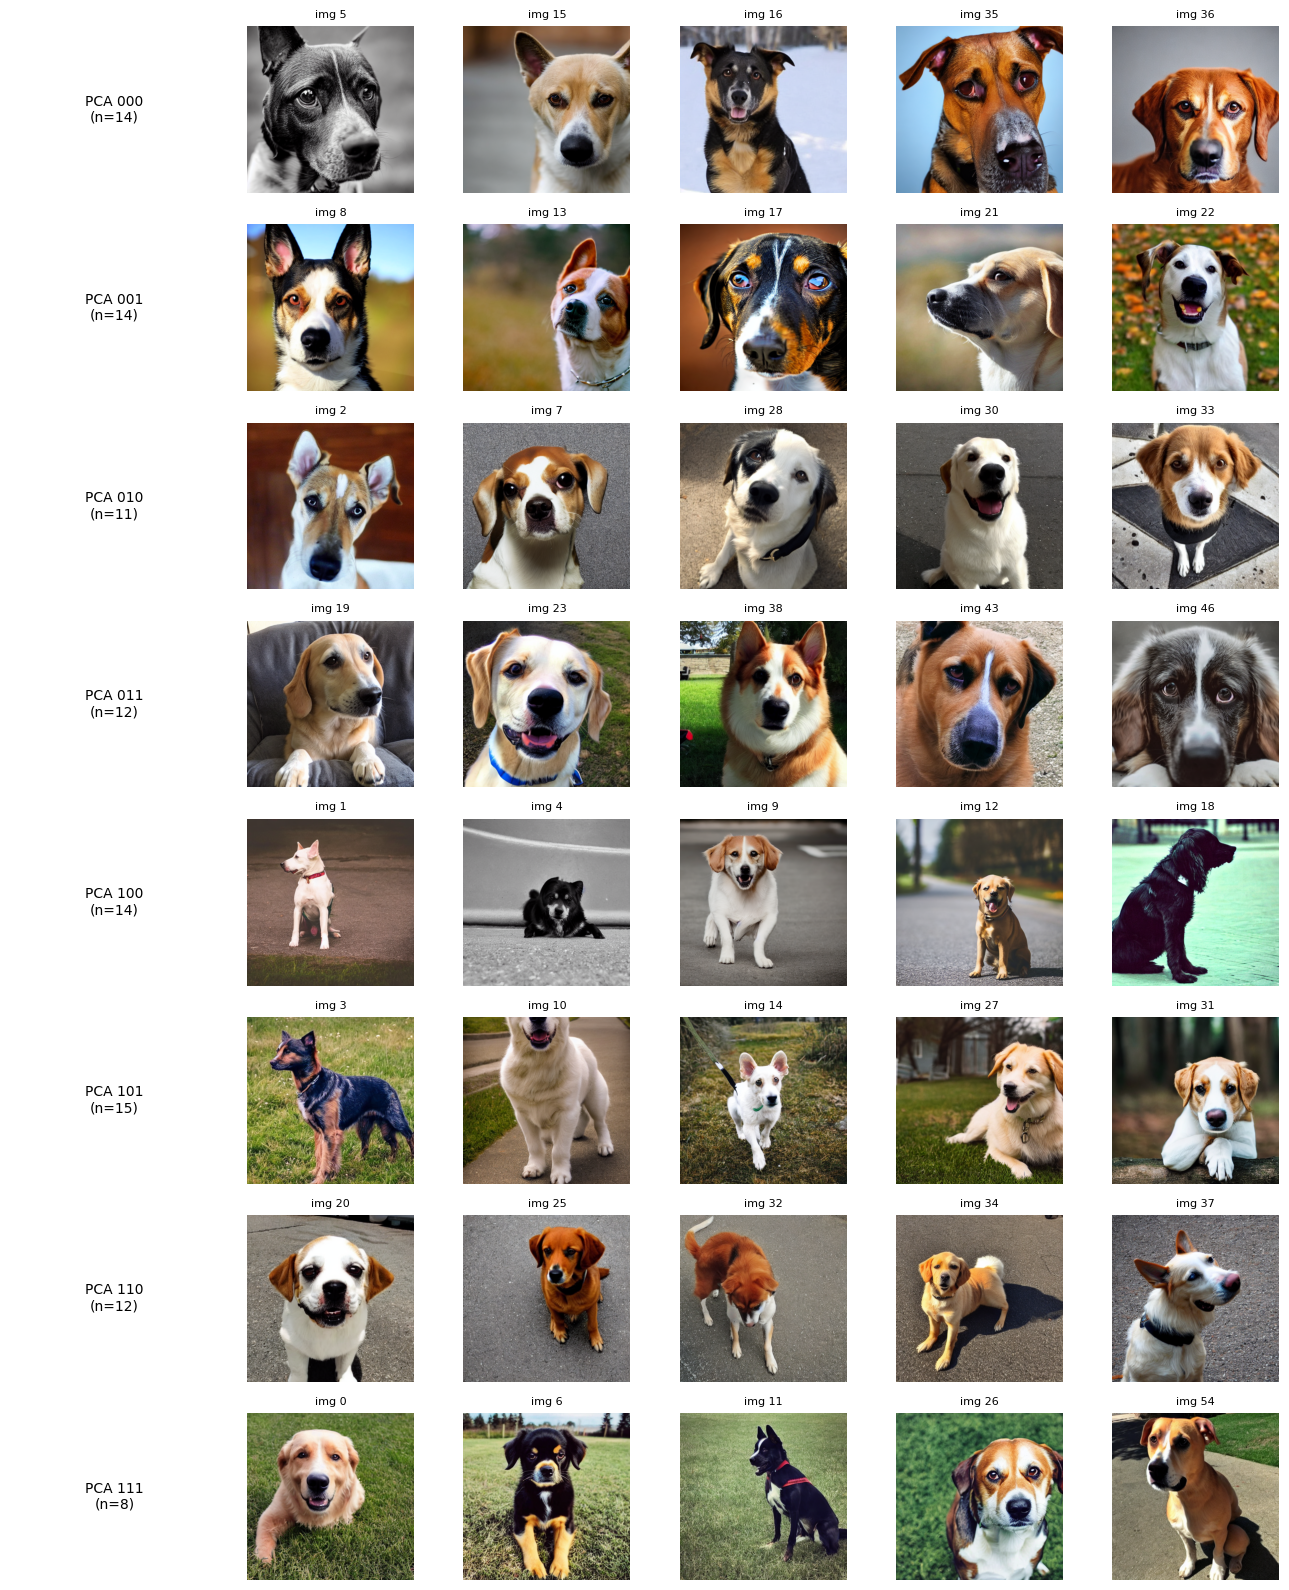

In [ ]:
# (b) PCA region별 대표 이미지 grid (region당 최대 5장)
max_show = 5
fig, axes = plt.subplots(
    N_REGIONS, 1 + max_show,
    figsize=(2.2 * (1 + max_show), 2.0 * N_REGIONS),
    squeeze=False,
)

for r in range(N_REGIONS):
    region_imgs = np.where(pca_region_id == r)[0]
    binary = format(r, f"0{K_select}b")
    axes[r, 0].text(
        0.5, 0.5, f"PCA {binary}\n(n={len(region_imgs)})",
        ha="center", va="center", fontsize=10,
    )
    axes[r, 0].axis("off")

    for col in range(max_show):
        ax = axes[r, col + 1]
        if col < len(region_imgs):
            ax.imshow(images[region_imgs[col]])
            ax.set_title(f"img {region_imgs[col]}", fontsize=8)
        else:
            ax.set_visible(False)
        ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# (c)(d) 요약 + 한 줄 결론
sim = "비슷" if ari > 0.5 and nmi > 0.5 else "부분적으로 유사" if ari > 0.2 else "다름"
print("=" * 60)
print(f"(c) Adjusted Rand Index     : {ari:.4f}")
print(f"(c) Normalized Mutual Info  : {nmi:.4f}")
print(f"(d) Dam entropy             : {dam_H:.4f} bits")
print(f"(d) PCA entropy             : {pca_H:.4f} bits")
print(f"(d) 더 imbalanced           : {more_imbalanced} (lower entropy)")
print("=" * 60)
print(
    f"결론: PCA region은 GEGLU(Dam) region과 {sim}함 "
    f"(ARI={ari:.3f}, NMI={nmi:.3f}); "
    f"mode 분포는 {more_imbalanced} 쪽이 더 쏠림(entropy {'낮음' if more_imbalanced != '동일' else '동일'})."
)

(c) Adjusted Rand Index     : 0.1193
(c) Normalized Mutual Info  : 0.3095
(d) Dam entropy             : 2.4240 bits
(d) PCA entropy             : 2.9778 bits
(d) 더 imbalanced           : Dam (lower entropy)
결론: PCA region은 GEGLU(Dam) region과 다름함 (ARI=0.119, NMI=0.310); mode 분포는 Dam 쪽이 더 쏠림(entropy 낮음).


---

# Baseline 2: K-means (K=8) vs Dam GEGLU hyperplane regions

**목적:** GEGLU gate hyperplane region 분할의 baseline으로, `image_repr`에 K-means(K=8)를 적용해 Dam(`04_DB_concept`)과 비교.

**입력:** `inputs`, `images`, `region_id` (Dam) — 위 셀에서 로드된 상태 가정.

In [19]:
from sklearn.cluster import KMeans

K_KMEANS = 8
try:
    image_repr
except NameError:
    image_repr = inputs.mean(dim=1).numpy()  # (N, C)

kmeans = KMeans(n_clusters=K_KMEANS, random_state=42, n_init=10)
kmeans_region_id = kmeans.fit_predict(image_repr)

print("K-means region distribution:", Counter(kmeans_region_id))
print("Dam region distribution:   ", Counter(region_id))

K-means region distribution: Counter({1: 17, 0: 14, 3: 14, 2: 13, 4: 12, 5: 11, 7: 10, 6: 9})
Dam region distribution:    Counter({7: 40, 0: 20, 5: 13, 2: 9, 3: 9, 1: 6, 6: 2, 4: 1})


In [ ]:
km_counts = np.array([Counter(kmeans_region_id).get(r, 0) for r in range(K_KMEANS)])
dam_counts_km = np.array([Counter(region_id).get(r, 0) for r in range(K_KMEANS)])
labels_km = [f"c{r}" for r in range(K_KMEANS)]

ari_km = adjusted_rand_score(region_id, kmeans_region_id)
nmi_km = normalized_mutual_info_score(region_id, kmeans_region_id)
dam_H_km = region_entropy(region_id, n_regions=K_KMEANS)
km_H = region_entropy(kmeans_region_id, n_regions=K_KMEANS)
more_imbalanced_km = "Dam" if dam_H_km < km_H else "K-means" if km_H < dam_H_km else "동일"

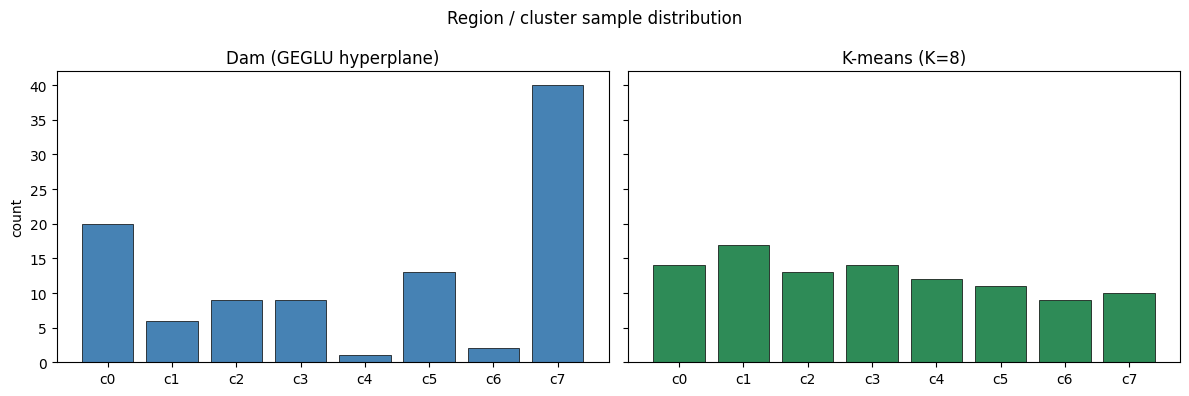

In [21]:
# (a) cluster별 sample 분포 — Dam vs K-means
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
x = np.arange(K_KMEANS)

axes[0].bar(x, dam_counts_km, color="steelblue", edgecolor="k", linewidth=0.5)
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels_km)
axes[0].set_title("Dam (GEGLU hyperplane)")
axes[0].set_ylabel("count")

axes[1].bar(x, km_counts, color="seagreen", edgecolor="k", linewidth=0.5)
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels_km)
axes[1].set_title("K-means (K=8)")

fig.suptitle("Region / cluster sample distribution", fontsize=12)
plt.tight_layout()
plt.show()

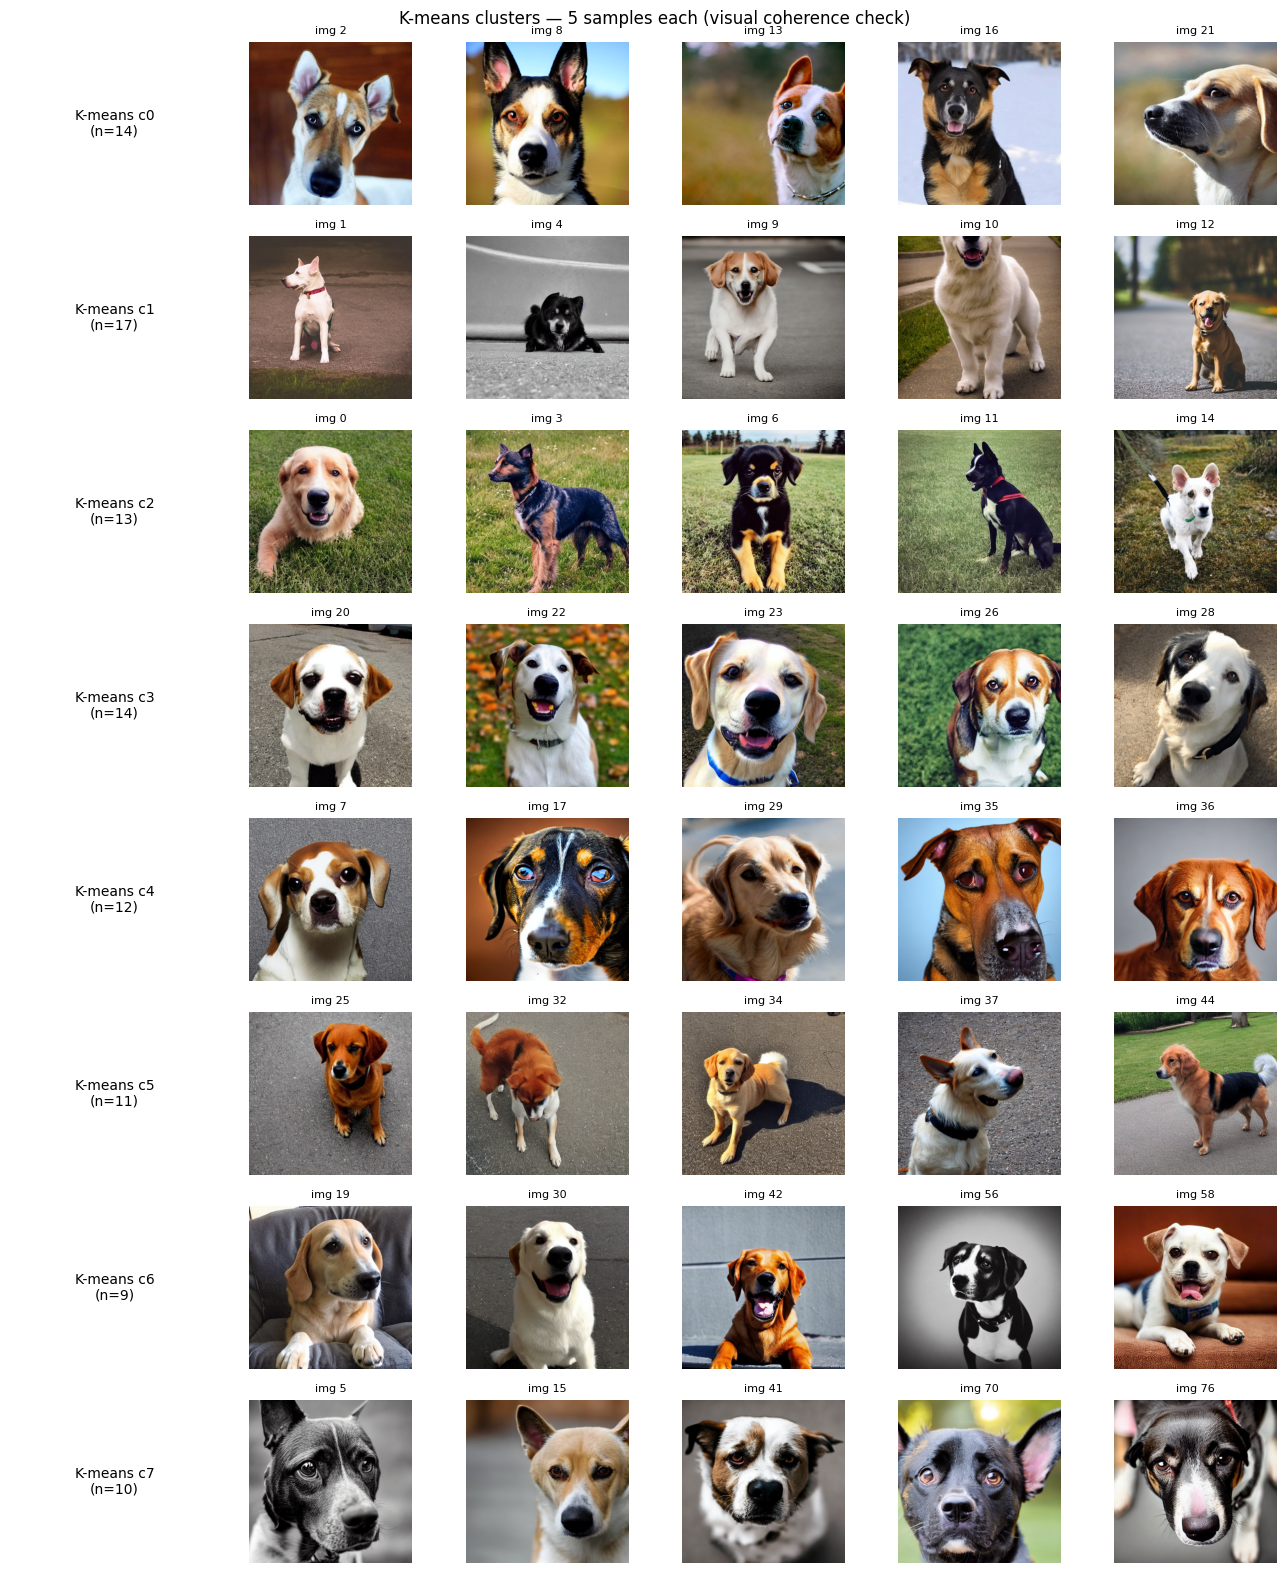

In [22]:
# (b)(e) K-means cluster별 이미지 5장 — 시각적 일관성 확인용
max_show = 5
fig, axes = plt.subplots(
    K_KMEANS, 1 + max_show,
    figsize=(2.2 * (1 + max_show), 2.0 * K_KMEANS),
    squeeze=False,
)

for r in range(K_KMEANS):
    cluster_imgs = np.where(kmeans_region_id == r)[0]
    axes[r, 0].text(
        0.5, 0.5, f"K-means c{r}\n(n={len(cluster_imgs)})",
        ha="center", va="center", fontsize=10,
    )
    axes[r, 0].axis("off")

    for col in range(max_show):
        ax = axes[r, col + 1]
        if col < len(cluster_imgs):
            ax.imshow(images[cluster_imgs[col]])
            ax.set_title(f"img {cluster_imgs[col]}", fontsize=8)
        else:
            ax.set_visible(False)
        ax.axis("off")

plt.suptitle("K-means clusters — 5 samples each (visual coherence check)", fontsize=12)
plt.tight_layout()
plt.show()

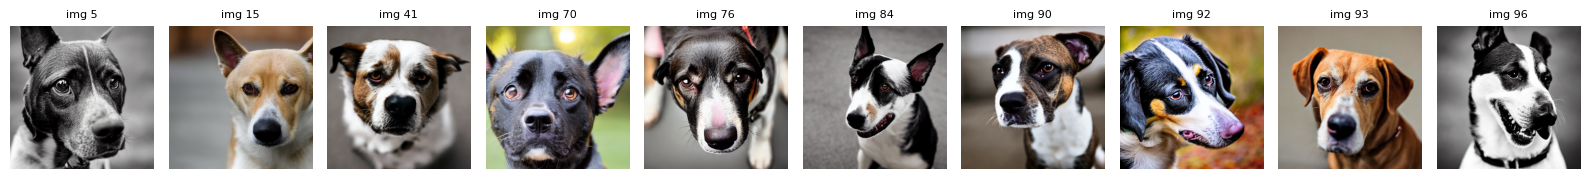

In [44]:
clust_imgs = np.where(kmeans_region_id == 7)[0]
col = 10
row = len(clust_imgs) // col + (1 if len(clust_imgs) % col > 0 else 0)
fig, axes = plt.subplots(row, col, figsize=(16, 2*row))

if row == 1:
    axes = np.expand_dims(axes, 0)
if col == 1:
    axes = np.expand_dims(axes, 1)

for idx, img_idx in enumerate(clust_imgs):
    r = idx // col
    c = idx % col
    axes[r, c].imshow(images[img_idx])
    axes[r, c].set_title(f'img {img_idx}', fontsize=8)
    axes[r, c].axis('off')

n_used = len(clust_imgs)
for idx in range(n_used, row * col):
    r = idx // col
    c = idx % col
    axes[r, c].axis('off')

plt.tight_layout()
plt.show()

In [23]:
# (c)(d) 요약 + 한 줄 결론
sim_km = "비슷" if ari_km > 0.5 and nmi_km > 0.5 else "부분적으로 유사" if ari_km > 0.2 else "다름"
print("=" * 60)
print(f"(c) Adjusted Rand Index     : {ari_km:.4f}")
print(f"(c) Normalized Mutual Info  : {nmi_km:.4f}")
print(f"(d) Dam entropy             : {dam_H_km:.4f} bits")
print(f"(d) K-means entropy         : {km_H:.4f} bits")
print(f"(d) 더 imbalanced           : {more_imbalanced_km} (lower entropy)")
print("=" * 60)
print(
    f"결론: K-means cluster는 GEGLU(Dam) region과 {sim_km}함 "
    f"(ARI={ari_km:.3f}, NMI={nmi_km:.3f}); "
    f"mode 분포는 {more_imbalanced_km} 쪽이 더 쏠림. "
    f"위 grid로 K-means vs Dam 중 어느 쪽 cluster/region이 시각적으로 더 일관된지 비교하세요."
)

(c) Adjusted Rand Index     : 0.1682
(c) Normalized Mutual Info  : 0.4054
(d) Dam entropy             : 2.4240 bits
(d) K-means entropy         : 2.9737 bits
(d) 더 imbalanced           : Dam (lower entropy)
결론: K-means cluster는 GEGLU(Dam) region과 다름함 (ARI=0.168, NMI=0.405); mode 분포는 Dam 쪽이 더 쏠림. 위 grid로 K-means vs Dam 중 어느 쪽 cluster/region이 시각적으로 더 일관된지 비교하세요.


In [24]:
# optional sanity: cluster 수 K에 따른 entropy
for k in [3, 5, 8, 10]:
    lbl = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(image_repr)
    H = region_entropy(lbl, n_regions=k)
    print(f"K={k:2d}  entropy={H:.4f} bits  counts={np.bincount(lbl, minlength=k)}")

K= 3  entropy=1.5776 bits  counts=[30 32 38]
K= 5  entropy=2.3127 bits  counts=[19 24 20 17 20]
K= 8  entropy=2.9737 bits  counts=[14 17 13 14 12 11  9 10]
K=10  entropy=3.1784 bits  counts=[ 8  6 20 13  4 15  7  9 11  7]


---

# Baseline 3: Random GEGLU hyperplanes vs Dam (top-balance) hyperplanes

**목적:** top-balance로 고른 3개 neuron hyperplane이 우연히 좋은 것이 아닌지 검증 — 전체 5120 neuron 중 random 3개( Dam 선택 제외 )로 같은 8-way 분할을 만들어 Dam과 비교.

**선행 (04_DB_concept):** `inputs`, `images`, `region_id`, `W2`, `b2`, `top_k_idx`, `selected_neurons`

In [34]:
top_k_idx = np.array([3945, 4797, 2894, 1027, 4374, 3087, 1589, 3371,  324,  753,  747, 3761,
         133, 1904, 4362, 4359,  208, 1965, 2185, 1287, 3533, 2911, 3810, 3167,
         163, 2757, 1607, 2787, 2225, 1356, 2645, 3145, 2829, 2058,   11, 1790,
        1831,  115, 3123, 1688, 1178, 4995, 4141, 4813,  523,  346, 2806,  377,
        4092,  110, 3800, 4456, 3454, 1452, 4754, 2993, 2223, 3394, 1574, 3934,
        2671, 4738, 4271, 4934, 4341, 1192,  458, 3209, 4711,  947, 1255, 1313,
        4404, 4881, 4778,  767,  800,  211,  763, 3603,  994, 2616, 4940, 5059,
        4500, 3061,  686, 4064,  139, 4392, 2371,  198, 3246,  635,  142, 4454,
         896,  496, 3184,  898])
selected_neurons = [51, 49, 18]

In [38]:
from diffusers import StableDiffusionPipeline

def get_target_block(unet, target_block_name: str):
    parts = target_block_name.split(".")
    def resolve(obj, remaining):
        if not remaining:
            return obj
        part, *rest = remaining
        child = obj[int(part)] if part.isdigit() else getattr(obj, part)
        return resolve(child, rest)
    return resolve(unet, parts)

pipe = StableDiffusionPipeline.from_pretrained("runwayml/stable-diffusion-v1-5")
pipe = pipe.to('cuda')
pipe.safety_checker = None
pipe.set_progress_bar_config(disable=True)

ff = get_target_block(pipe.unet, TARGET_BLOCK)
ff_state = ff.state_dict()

W_geglu = ff_state["proj.weight"].cpu().float()   # (10240, 1280)
n_geglu_half = W_geglu.shape[0] // 2

W2 = W_geglu[n_geglu_half:]
b_geglu = ff_state["proj.bias"].cpu().float()
b2 = b_geglu[n_geglu_half:]

In [39]:
K_select = 3
N_REGIONS = 8
RANDOM_RUN_SEEDS = [42, 43, 44, 45, 46]

# selected_neurons: top-K 리스트(0~K-1) 내 인덱스 → global neuron id
exclude_global = set(top_k_idx[np.array(selected_neurons)].tolist())
pool = np.setdiff1d(np.arange(W2.shape[0]), list(exclude_global))
print(f"exclude (Dam) global neurons: {sorted(exclude_global)}")
print(f"random pool size: {len(pool)}")

exclude (Dam) global neurons: [110, 2185, 4456]
random pool size: 5117


In [40]:
def random_region_from_neurons(neuron_idx):
    """neuron_idx: length-3 global indices into W2."""
    W_r = W2[neuron_idx].float()  # (3, C)
    b_r = b2[neuron_idx].float()  # (3,)
    sd = inputs @ W_r.T + b_r
    sd = sd / W_r.norm(dim=-1)
    per_image_pos_ratio = (sd > 0).float().mean(dim=1)  # (N, 3)
    image_signs = (per_image_pos_ratio > 0.5).int().cpu().numpy()
    return image_signs[:, 0] * 4 + image_signs[:, 1] * 2 + image_signs[:, 2]


entropies_rand, aris_rand = [], []
random_region_id_show = None
random_idx_show = None

for seed in RANDOM_RUN_SEEDS:
    rng = np.random.RandomState(seed)
    rand_idx = rng.choice(pool, size=K_select, replace=False)
    rid = random_region_from_neurons(rand_idx)
    entropies_rand.append(region_entropy(rid, N_REGIONS))
    aris_rand.append(adjusted_rand_score(region_id, rid))
    if seed == RANDOM_RUN_SEEDS[0]:
        random_region_id_show = rid
        random_idx_show = rand_idx
    print(f"seed={seed}  neurons={rand_idx.tolist()}  H={entropies_rand[-1]:.4f}  ARI={aris_rand[-1]:.4f}")

dam_H_rand = region_entropy(region_id, N_REGIONS)
mean_H_rand = np.mean(entropies_rand)
mean_ARI = np.mean(aris_rand)
std_H_rand = np.std(entropies_rand)
std_ARI = np.std(aris_rand)

seed=42  neurons=[531, 5006, 4990]  H=-0.0000  ARI=0.0000
seed=43  neurons=[853, 3413, 3386]  H=-0.0000  ARI=0.0000
seed=44  neurons=[272, 3216, 235]  H=0.0808  ARI=-0.0087
seed=45  neurons=[4955, 1653, 5082]  H=0.9988  ARI=0.0161
seed=46  neurons=[1764, 3815, 1923]  H=-0.0000  ARI=0.0000


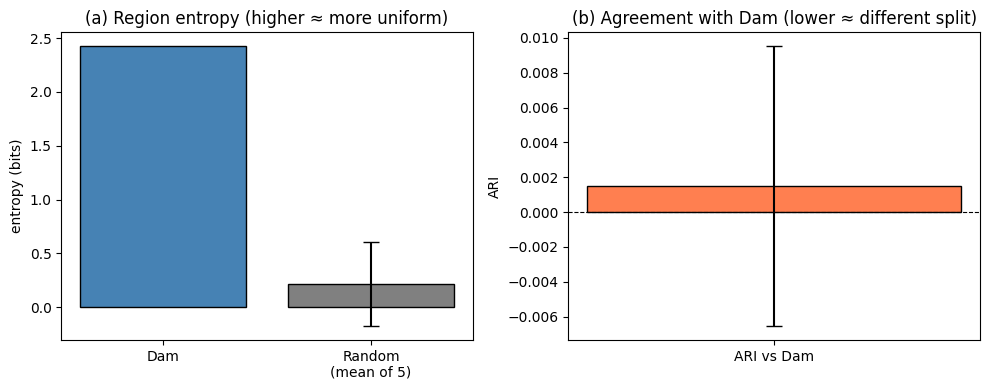

Dam entropy     : 2.4240
Random entropy  : 0.2159 ± 0.3927
Random ARI      : 0.0015 ± 0.0080


In [41]:
# (a)(b) Dam vs Random (5-run 평균)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(["Dam", f"Random\n(mean of {len(RANDOM_RUN_SEEDS)})"], [dam_H_rand, mean_H_rand],
            color=["steelblue", "gray"], edgecolor="k")
axes[0].errorbar([1], [mean_H_rand], yerr=[std_H_rand], fmt="none", color="k", capsize=6)
axes[0].set_ylabel("entropy (bits)")
axes[0].set_title("(a) Region entropy (higher ≈ more uniform)")

axes[1].bar(["ARI vs Dam"], [mean_ARI], color="coral", edgecolor="k")
axes[1].errorbar([0], [mean_ARI], yerr=[std_ARI], fmt="none", color="k", capsize=6)
axes[1].axhline(0, color="k", lw=0.8, ls="--")
axes[1].set_ylabel("ARI")
axes[1].set_title("(b) Agreement with Dam (lower ≈ different split)")

plt.tight_layout()
plt.show()

print(f"Dam entropy     : {dam_H_rand:.4f}")
print(f"Random entropy  : {mean_H_rand:.4f} ± {std_H_rand:.4f}")
print(f"Random ARI      : {mean_ARI:.4f} ± {std_ARI:.4f}")

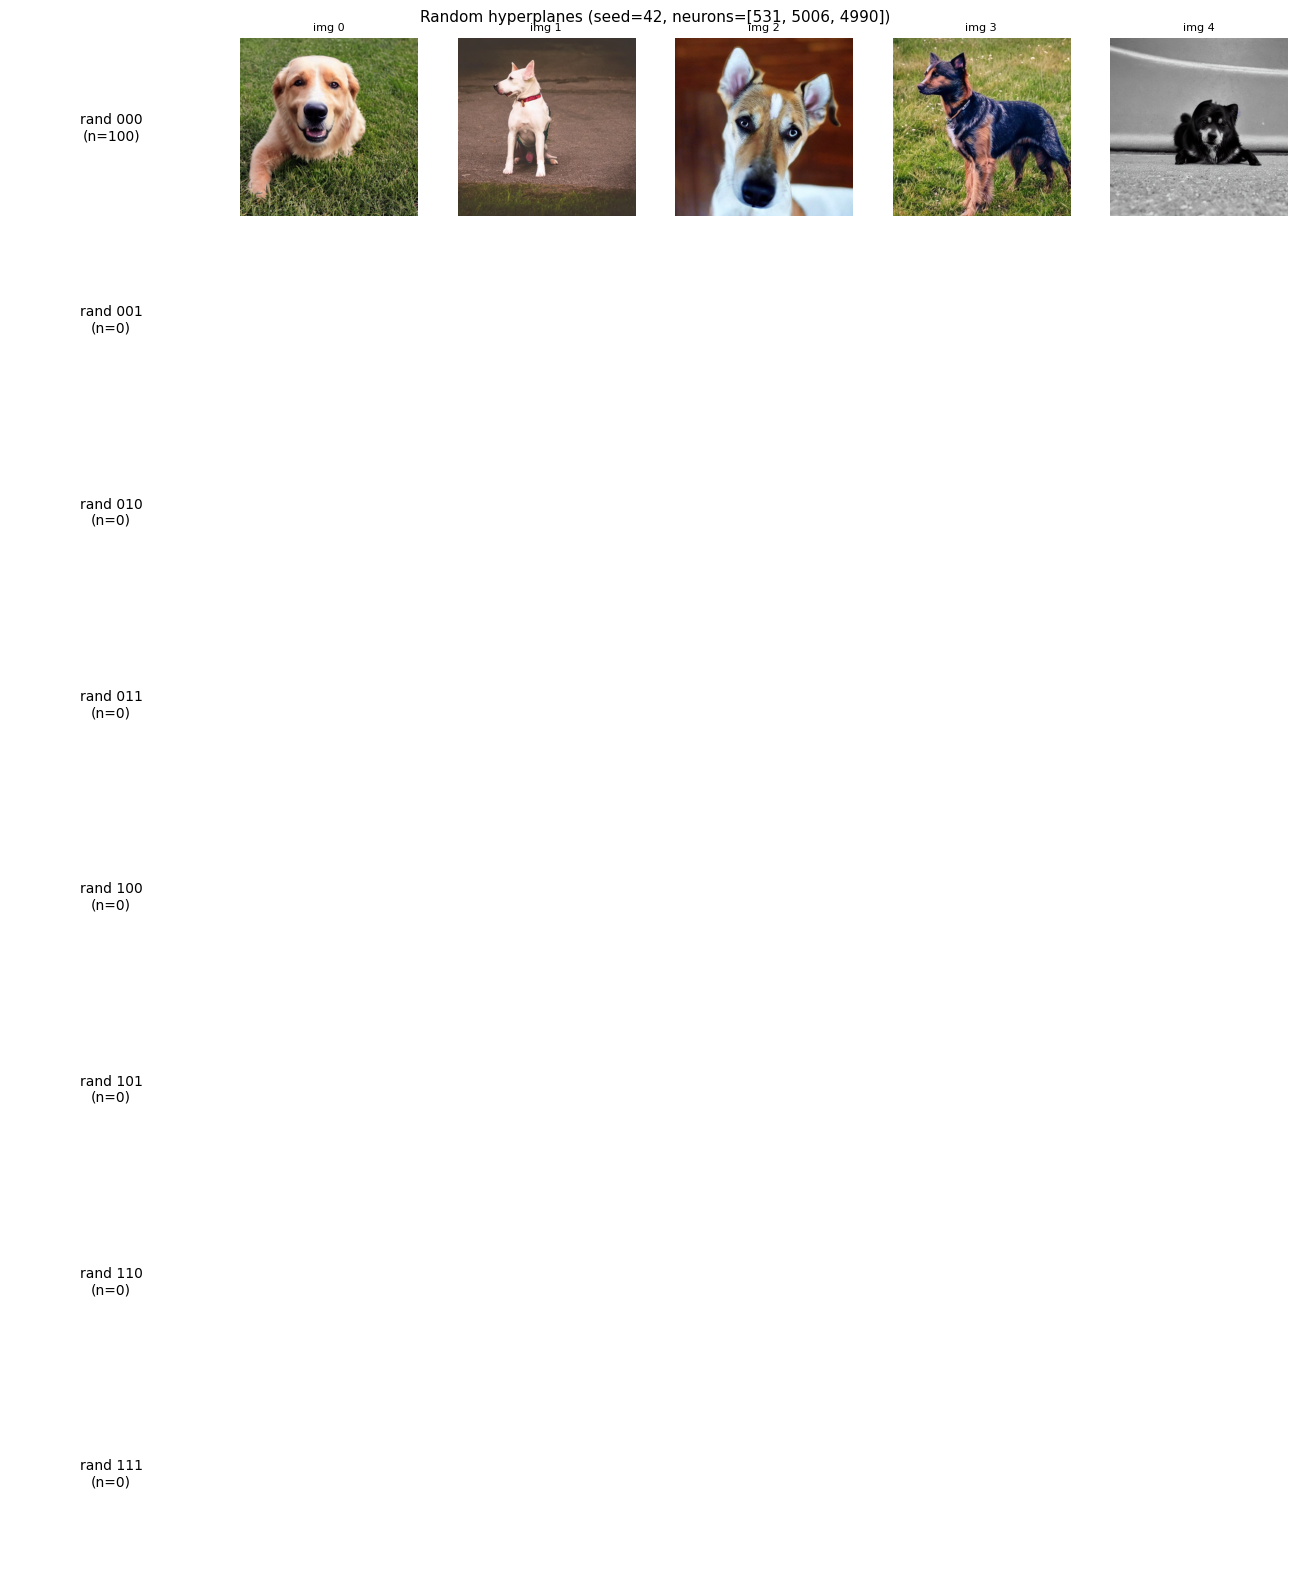

In [42]:
# (c) 1번 run (seed=42) — random region별 이미지 5장 (시각적 일관성)
max_show = 5
fig, axes = plt.subplots(
    N_REGIONS, 1 + max_show,
    figsize=(2.2 * (1 + max_show), 2.0 * N_REGIONS),
    squeeze=False,
)

for r in range(N_REGIONS):
    r_imgs = np.where(random_region_id_show == r)[0]
    binary = format(r, f"0{K_select}b")
    axes[r, 0].text(
        0.5, 0.5, f"rand {binary}\n(n={len(r_imgs)})",
        ha="center", va="center", fontsize=10,
    )
    axes[r, 0].axis("off")
    for col in range(max_show):
        ax = axes[r, col + 1]
        if col < len(r_imgs):
            ax.imshow(images[r_imgs[col]])
            ax.set_title(f"img {r_imgs[col]}", fontsize=8)
        else:
            ax.set_visible(False)
        ax.axis("off")

plt.suptitle(
    f"Random hyperplanes (seed={RANDOM_RUN_SEEDS[0]}, neurons={random_idx_show.tolist()})",
    fontsize=11,
)
plt.tight_layout()
plt.show()

In [43]:
# 결론
higher_rand = mean_H_rand > dam_H_rand
low_ari = mean_ARI < 0.15
print("=" * 60)
print(f"Dam entropy              : {dam_H_rand:.4f}")
print(f"Random entropy (5-run)   : {mean_H_rand:.4f} ± {std_H_rand:.4f}")
print(f"Random ARI vs Dam        : {mean_ARI:.4f} ± {std_ARI:.4f}")
print("=" * 60)
if higher_rand and low_ari:
    verdict = "아니오 — random hyperplane은 Dam만큼 의미 있는 mode 분할을 주지 않음 (entropy↑, ARI≈0)."
elif higher_rand:
    verdict = "부분적 — random은 entropy는 더 높으나 Dam과 분할이 어느 정도 겹침."
else:
    verdict = "예외적 — random도 Dam과 비슷한 entropy; grid로 시각적 일관성을 추가 확인."
print(f"결론: {verdict}")

Dam entropy              : 2.4240
Random entropy (5-run)   : 0.2159 ± 0.3927
Random ARI vs Dam        : 0.0015 ± 0.0080
결론: 예외적 — random도 Dam과 비슷한 entropy; grid로 시각적 일관성을 추가 확인.
